<a href="https://colab.research.google.com/github/isaacadebayo/Predictive-Analytics-Public-Datasets/blob/main/Unsupervised_learning_Clustering_Credit_Card_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/CC.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
data = df.drop('CUST_ID', axis=1)
data.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
data.isna().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [ ]:
data_filled = data.fillna(data['MINIMUM_PAYMENTS'].mean())
data_filled.isna().sum()
data_filled.head(20)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


# Scaling using standard scaler

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize features (important for t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_filled)
data_scaled = pd.DataFrame(X_scaled, columns=data.columns, index=data.index)

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

# Define the number of features for PCA
n_feat = 2 # Setting to 2 components for initial analysis/visualization

# Apply PCA on the scaled data (now a DataFrame: data_scaled)
pca = PCA(n_components=n_feat)
X_pca_array = pca.fit_transform(data_scaled)

# Create new column names for the principal components
pca_cols = [f'PC{i+1}' for i in range(n_feat)]

# Update data_scaled to contain the PCA-transformed data
data_scaled = pd.DataFrame(X_pca_array, columns=pca_cols, index=data_scaled.index)

# Clustering

# K-means / GMM (sweep through k values)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Range of clusters to try
k_range = np.arange(2, 20 + 1)

silhouette_scores_kmeans = []
silhouette_scores_gmm = []
aic_scores_gmm = []
bic_scores_gmm = []

for k in k_range:
    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels_kmeans = kmeans.fit_predict(data_scaled)
    score_kmeans = silhouette_score(data_scaled, labels_kmeans)
    silhouette_scores_kmeans.append(score_kmeans)

    # GMM
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(data_scaled)
    labels_gmm = gmm.predict(data_scaled)
    score_gmm = silhouette_score(data_scaled, labels_gmm)
    silhouette_scores_gmm.append(score_gmm)
    aic_scores_gmm.append(gmm.aic(data_scaled))
    bic_scores_gmm.append(gmm.bic(data_scaled))

# Silhouette + AIC / BIC

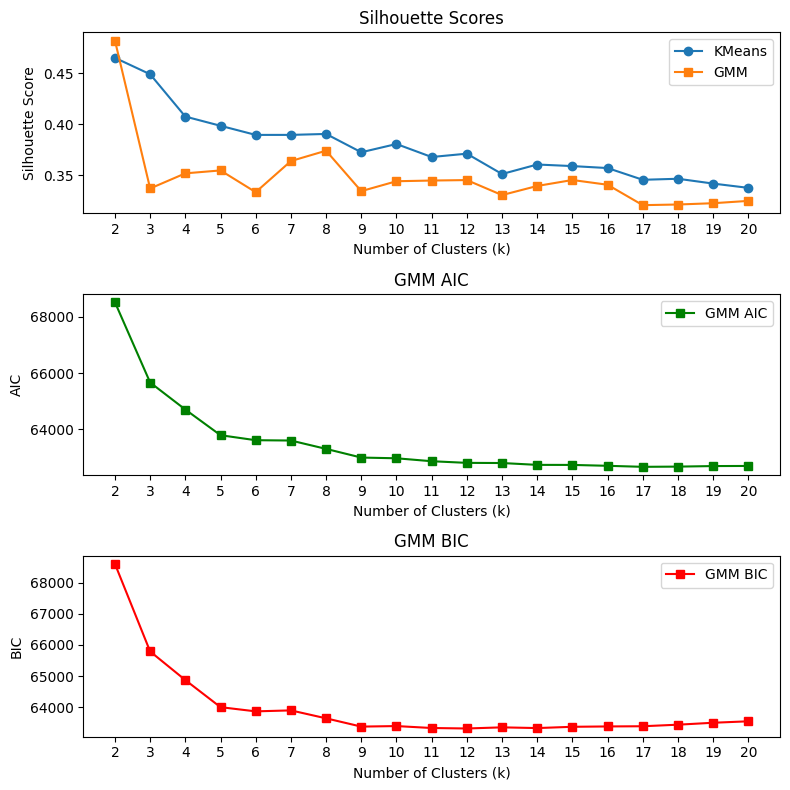

In [ ]:
# Plot all stacked vertically
plt.figure(figsize=(8, 8))

# Silhouette scores
plt.subplot(3, 1, 1)
plt.plot(k_range, silhouette_scores_kmeans, marker='o', label='KMeans')
plt.plot(k_range, silhouette_scores_gmm, marker='s', label='GMM')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.legend()

# AIC
plt.subplot(3, 1, 2)
plt.plot(k_range, aic_scores_gmm, marker='s', color='green', label='GMM AIC')
plt.title('GMM AIC')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('AIC')
plt.xticks(k_range)
plt.legend()

# BIC
plt.subplot(3, 1, 3)
plt.plot(k_range, bic_scores_gmm, marker='s', color='red', label='GMM BIC')
plt.title('GMM BIC')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('BIC')
plt.xticks(k_range)
plt.legend()

plt.tight_layout()
plt.show()

Evaluation of clustering explained

*   Silhouette score (higher score aree better indicating well separated clusters, both K-means and GMM show similar trend peaking around 2 or 3 and then decreeasing. Silhouette score was initially higher for k.
*   Akaike information criterion (lower AIC inidciate a bettwe model, AIC decrease as k increeased

*  Bayesian information criterion decreased as numnber of cluster k increased

k=2 and k = 3 could be a choice for GMM based on the sudden drop in AIC.






KMeans Cluster 0 mean silhouette: 0.278
KMeans Cluster 1 mean silhouette: 0.504


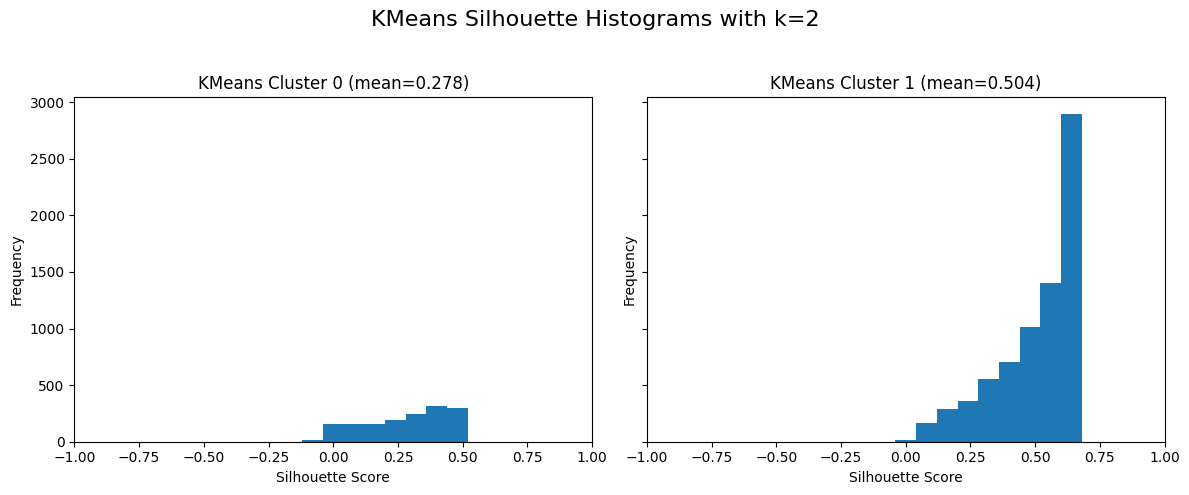

GMM Cluster 0 mean silhouette: 0.020
GMM Cluster 1 mean silhouette: 0.598


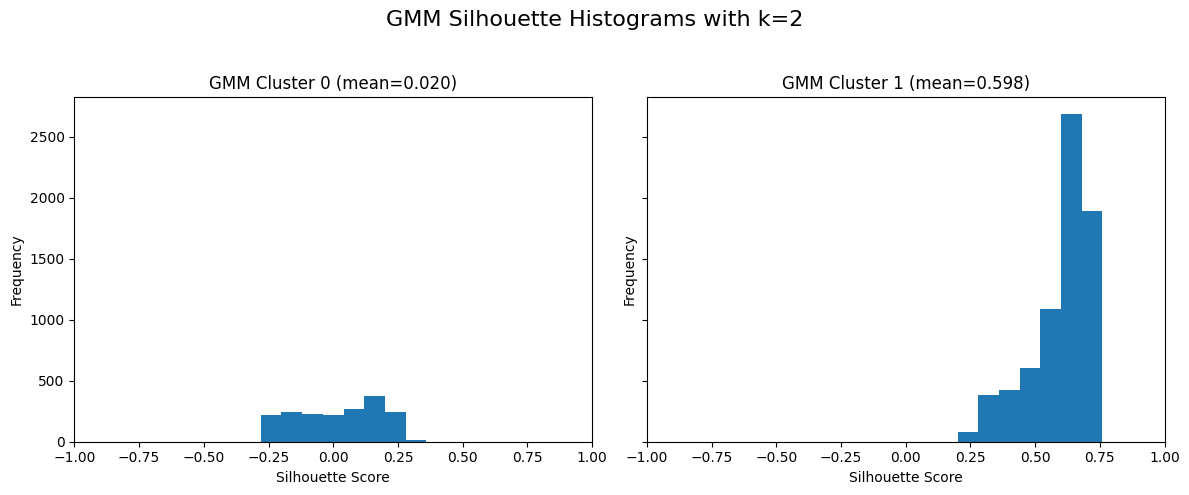

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# Number of clusters
n_clusters = 2

# Fit KMeans with 2 clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels_kmeans = kmeans.fit_predict(data_scaled)

# Fit GMM with 2 components
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
labels_gmm = gmm.fit_predict(data_scaled)

# Compute silhouette samples
sil_vals_kmeans = silhouette_samples(data_scaled, labels_kmeans)
sil_vals_gmm = silhouette_samples(data_scaled, labels_gmm)

# === KMeans Histograms: side by side ===
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 5), sharey=True)

for i in range(n_clusters):
    ax = axes[i]
    cluster_sil_vals = sil_vals_kmeans[labels_kmeans == i]
    mean_sil = cluster_sil_vals.mean()
    print(f"KMeans Cluster {i} mean silhouette: {mean_sil:.3f}")
    ax.hist(cluster_sil_vals, bins=25, range=(-1, 1) )
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Silhouette Score')
    ax.set_ylabel('Frequency')
    ax.set_title(f'KMeans Cluster {i} (mean={mean_sil:.3f})')

plt.suptitle(f'KMeans Silhouette Histograms with k={n_clusters}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# === GMM Histograms: side by side ===
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 5), sharey=True)

for i in range(n_clusters):
    ax = axes[i]
    cluster_sil_vals = sil_vals_gmm[labels_gmm == i]
    mean_sil = cluster_sil_vals.mean()
    print(f"GMM Cluster {i} mean silhouette: {mean_sil:.3f}")
    ax.hist(cluster_sil_vals, bins=25, range=(-1, 1) )
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Silhouette Score')
    ax.set_ylabel('Frequency')
    ax.set_title(f'GMM Cluster {i} (mean={mean_sil:.3f})')

plt.suptitle(f'GMM Silhouette Histograms with k={n_clusters}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

For n_cluster=2 both K-Means and GMM were analyzed.

*   KMeans Cluster 0 mean had a a silhouette score of 0.278
*   KMeans Cluster 1 mean had a silhouettee score of 0.504

Cluster 1 has a much higher silhouettee score indicating it is much better separated and more cohesive than cluster 0

GMM Silhouette Histogram

*    GMM Cluster 0 mean had a a silhouette score of 0.020
*    GMM Cluster 0 mean had a a silhouette score of 0.598

GMM Cluster 1 shows a good silhouette score while cluster 0 has a zero score.

# Crosstab

In [ ]:
# Create a DataFrame to hold both sets of labels
df_labels = pd.DataFrame({
    'kmeans': labels_kmeans,
    'gmm': labels_gmm
}, index=data_scaled.index)

# Crosstab with margins (adds totals)
ct = pd.crosstab(df_labels['kmeans'], df_labels['gmm'], margins=True)
display(ct)

gmm,0,1,All
kmeans,,,
0,944,601,1545
1,858,6547,7405
All,1802,7148,8950


cross tab shows the overlap between Kmeans and GMM labels when both are set to n_clusters=2. Helps undertaand how consistent the two algorithms are grouping the data

### Check Adjusted Rand Index and Mutual Info

Both range from $[-1,1]$ (like silhouette) with closer to 1 being more clustering agreement.

In [ ]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Example: compare KMeans and GMM
ari = adjusted_rand_score(labels_kmeans, labels_gmm)
ami = adjusted_mutual_info_score(labels_kmeans, labels_gmm)

print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")

ARI: 0.356
AMI: 0.187


ARI and AMI measure the similarity between two clusterings, ranging from -1 to 1. Where 1 indicates perfect agreemeent. 0.47 and 0.42 suggeest a moderate level of agreement between K-Means and GMM but not a strong one which also reflect the silhouette scores.

# Clustering against numerical feature distribution

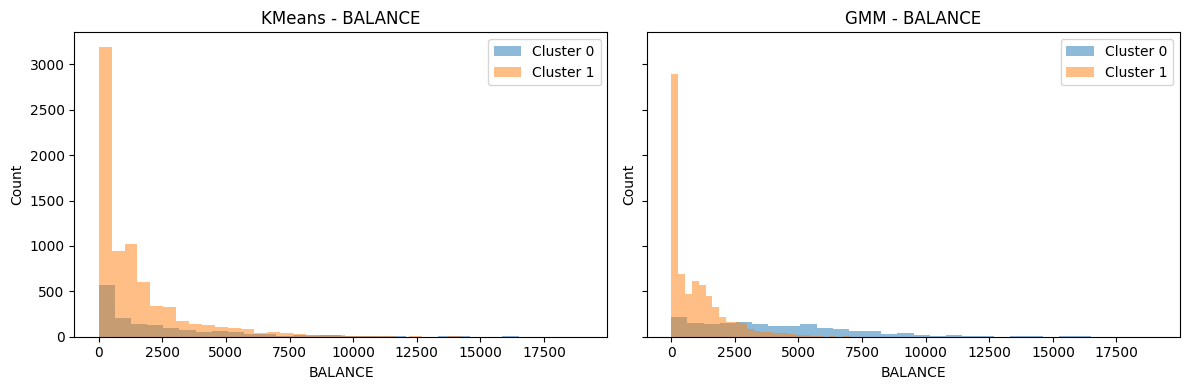

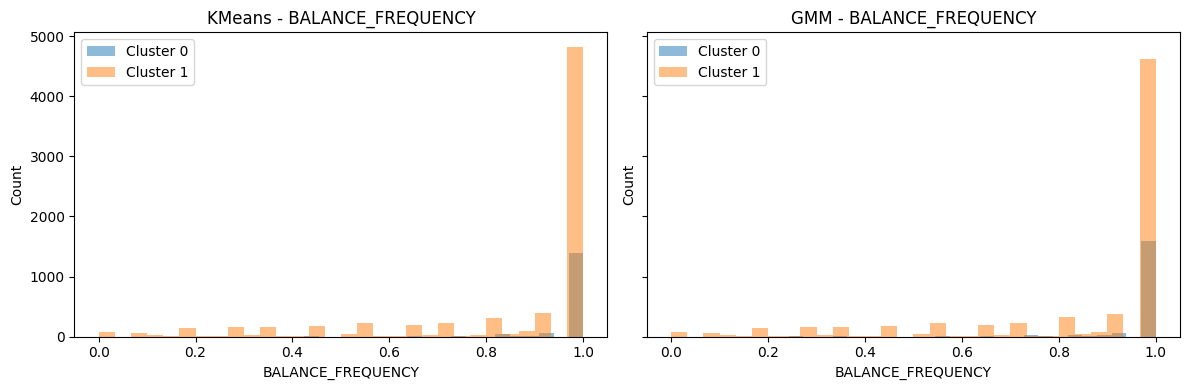

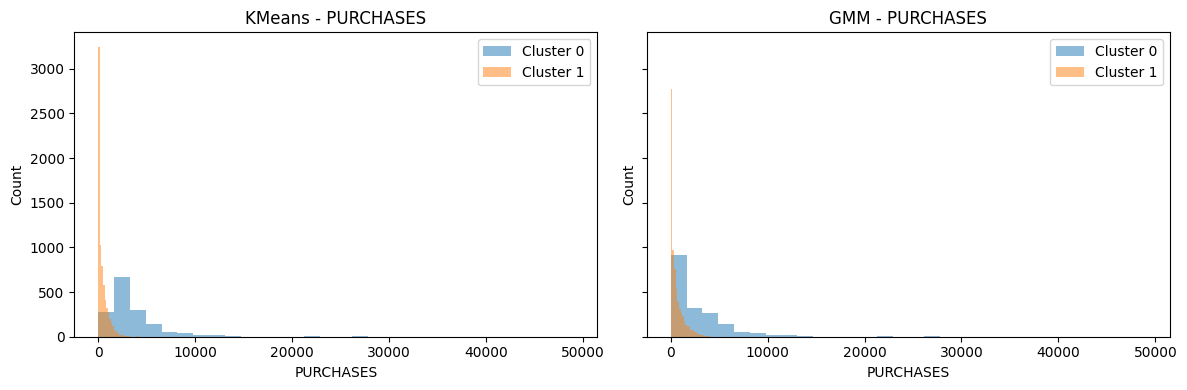

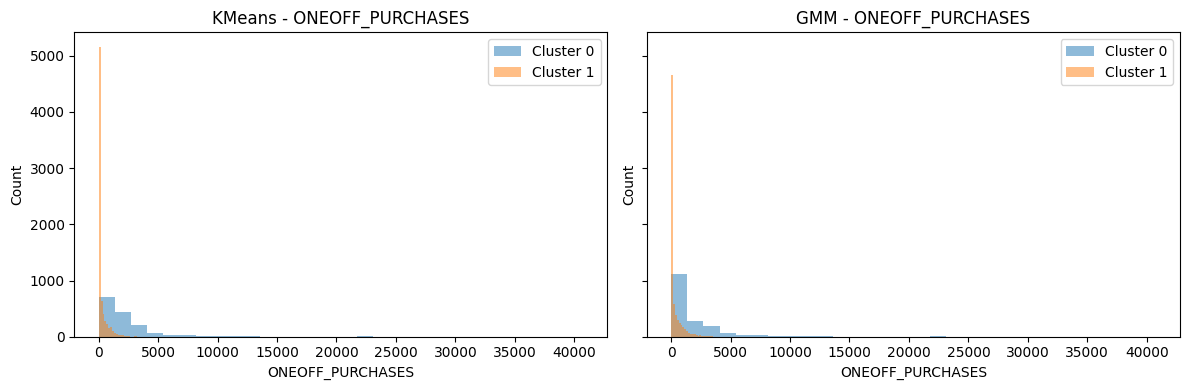

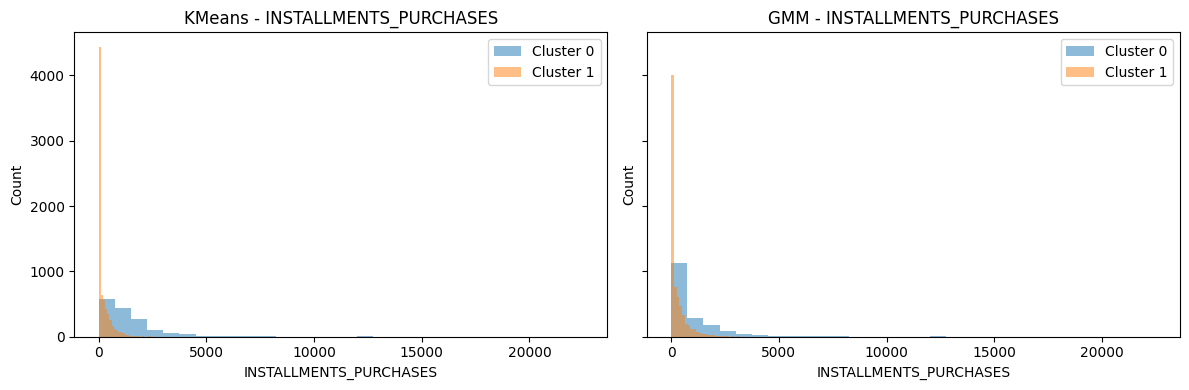

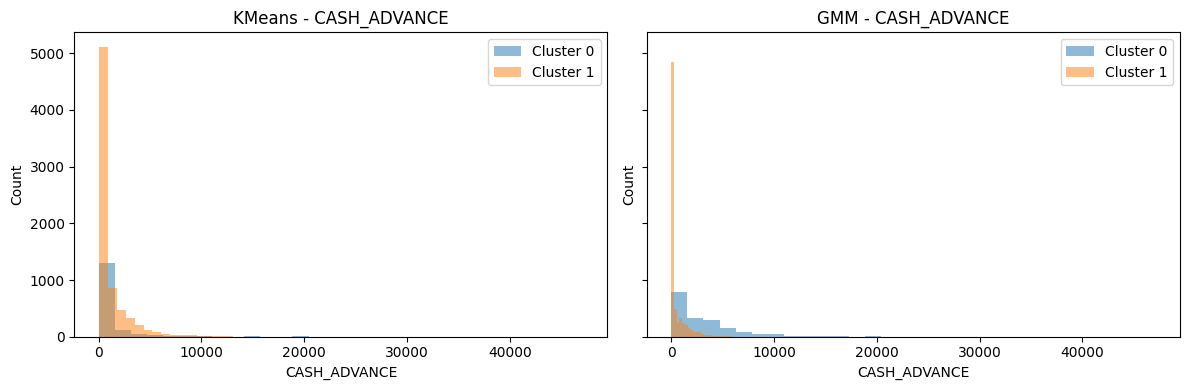

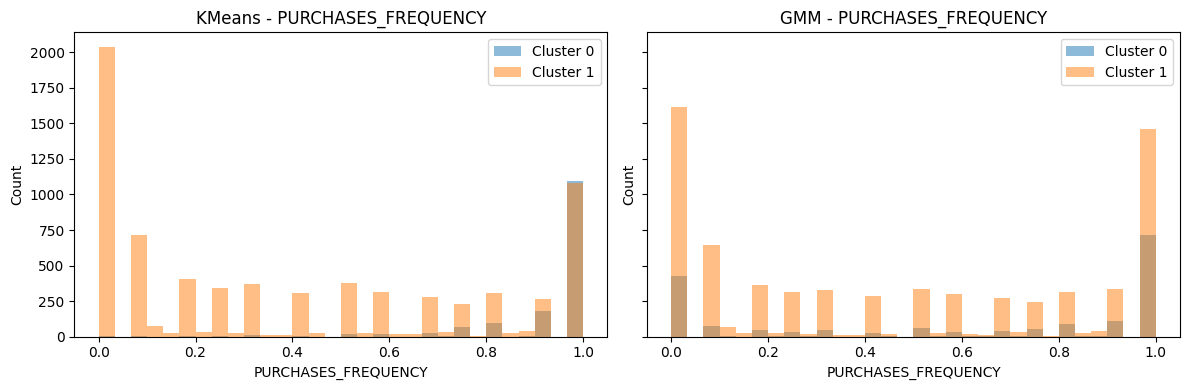

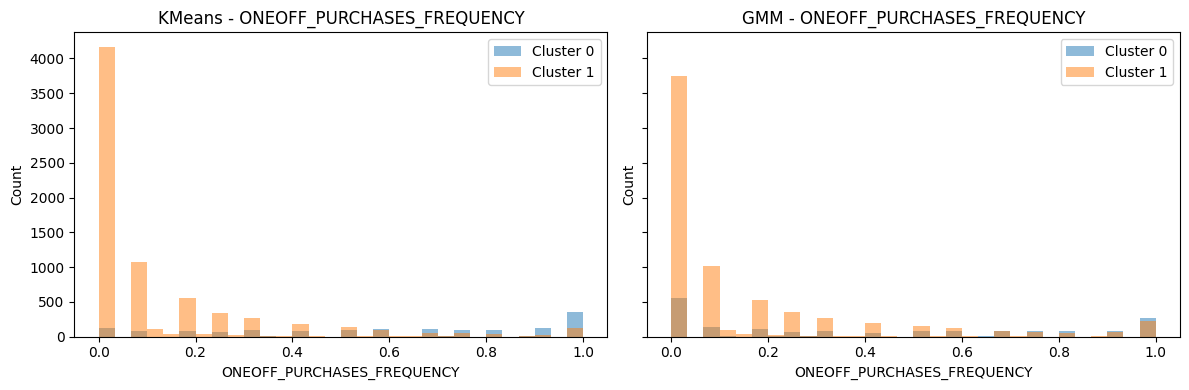

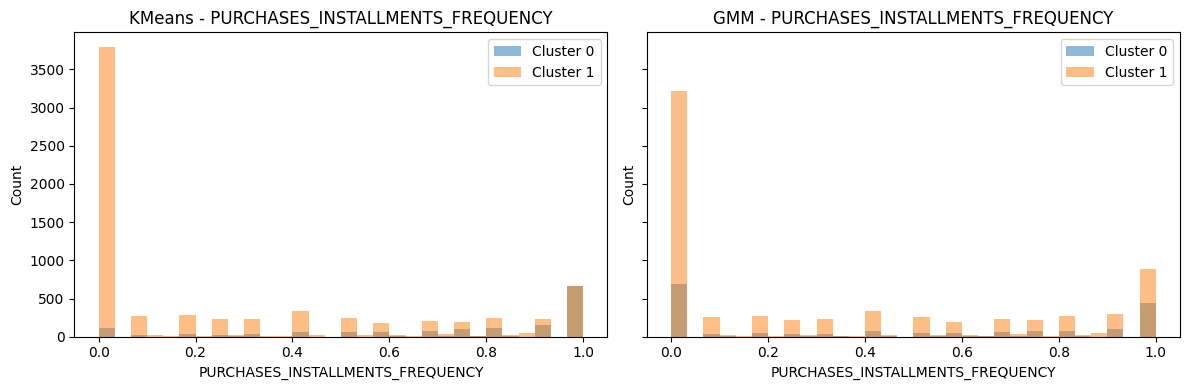

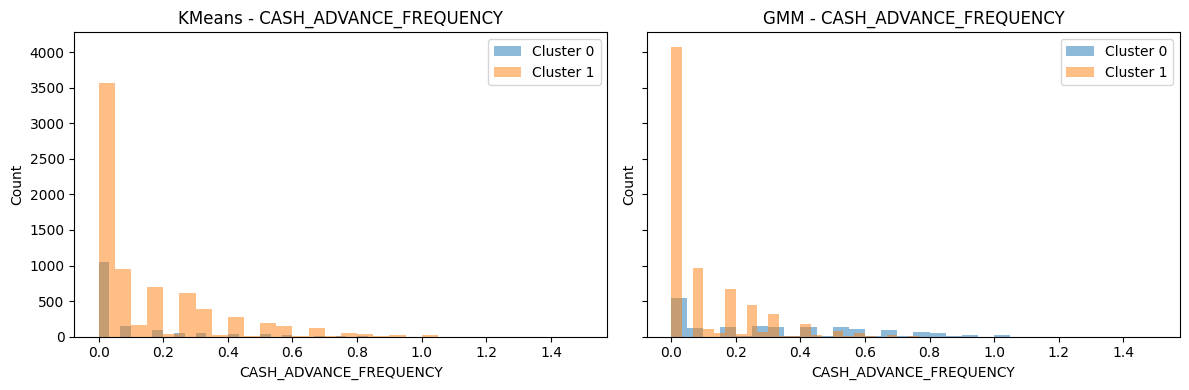

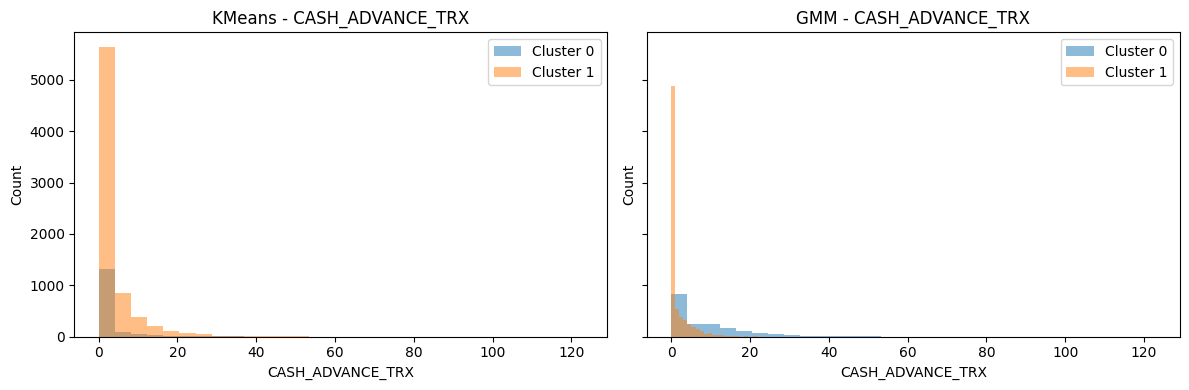

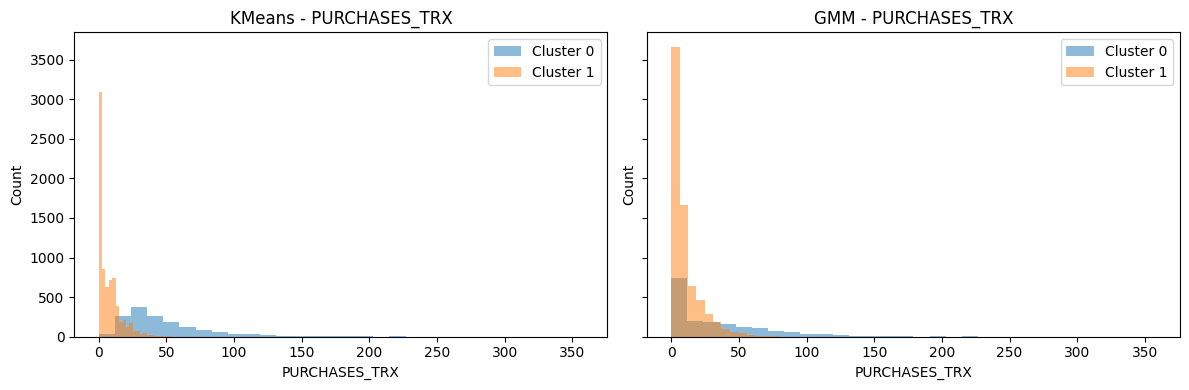

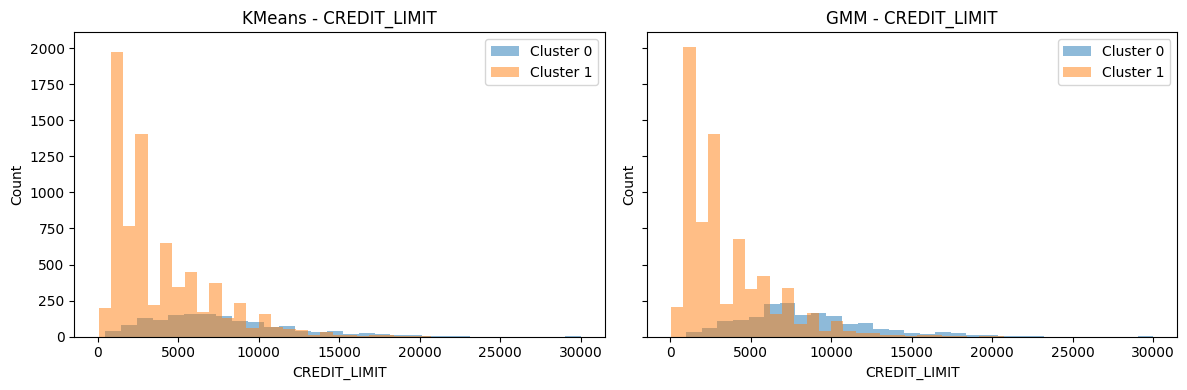

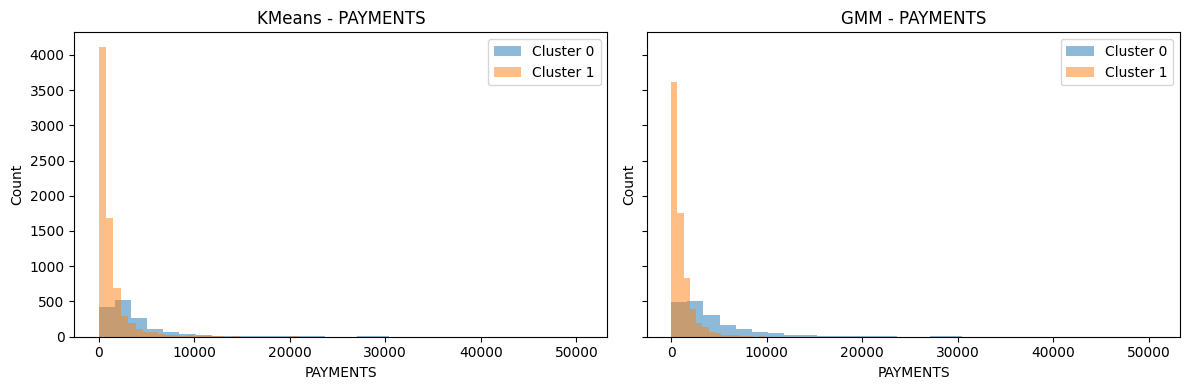

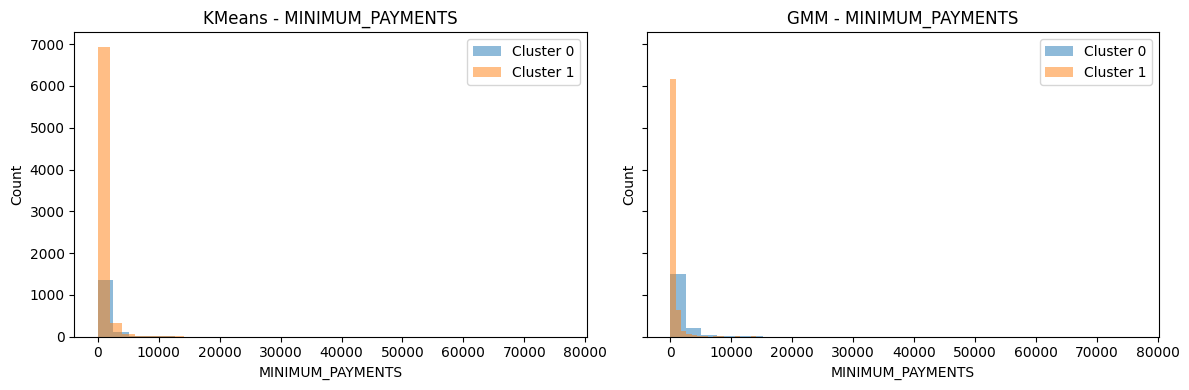

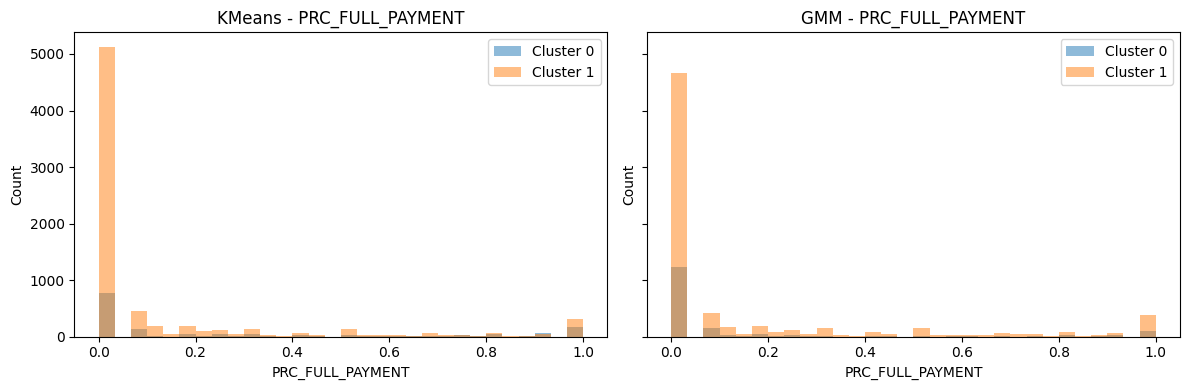

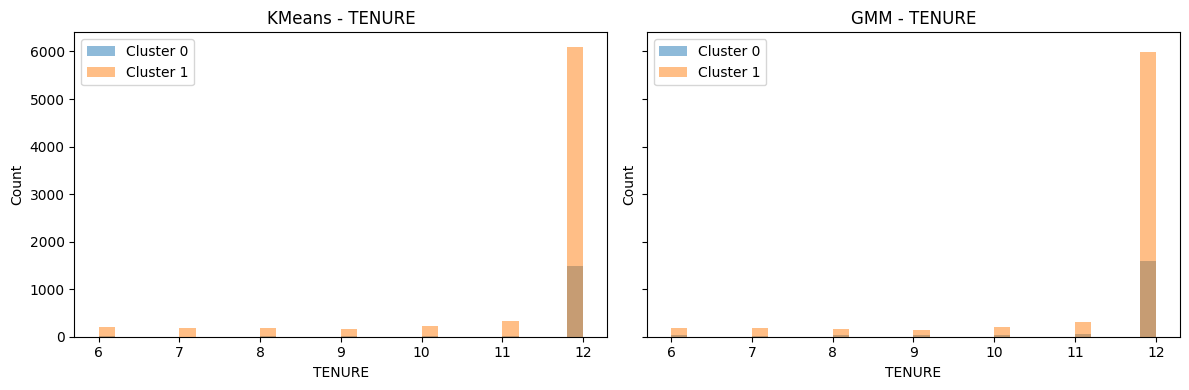

In [ ]:
# Loop through each feature
for feature in data_filled.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    # KMeans plot
    for label in sorted(df_labels['kmeans'].unique()):
        subset = data_filled[df_labels['kmeans'] == label][feature]
        axes[0].hist(subset, bins=30, alpha=0.5, label=f'Cluster {label}')
    axes[0].set_title(f'KMeans - {feature}')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Count')
    axes[0].legend()

    # GMM plot
    for label in sorted(df_labels['gmm'].unique()):
        subset = data_filled[df_labels['gmm'] == label][feature]
        axes[1].hist(subset, bins=30, alpha=0.5, label=f'Cluster {label}')
    axes[1].set_title(f'GMM - {feature}')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Count')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Visualize the distribution of both K-Means and GMM with n_clusters=2.

What to watch out for:

*   If a feature is bimodal (two peaks) it suggest that the cluster could be subdivided or that K-Means/GMM struggled to separate distinct groups basd on that feature

*   If a feature is concntrateed in onee cluster and sparse in another, it indicatees that this feature is a strong discriminatorr between those clusters.

*   Comparring the KMeans and GMM plots for eac feature allows you to understand if they define cluster is based on similar patterns in the data






## t-SNE visualization

t-SNE is a non-linear dimension reduction method that tries to preserves local neighbor relationships in data.

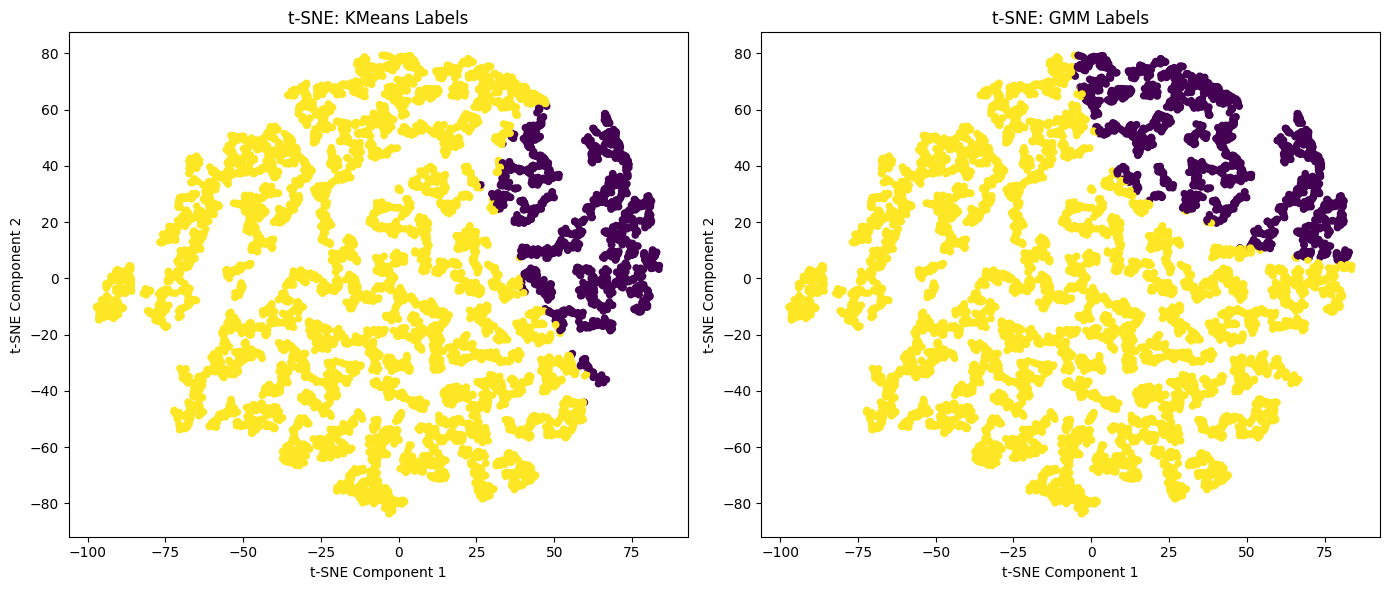

In [ ]:
from sklearn.manifold import TSNE

# Perform t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)
X_embedded = tsne.fit_transform(data_scaled)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KMeans plot
axes[0].scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels_kmeans, s=20, cmap='viridis')
axes[0].set_title('t-SNE: KMeans Labels')
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')

# GMM plot
axes[1].scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels_gmm, s=20, cmap='viridis')
axes[1].set_title('t-SNE: GMM Labels')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')

plt.tight_layout()
plt.show()

t-SNE reeduce data to two dimension for visulaization. Plot help to visually inspect if

Clusters should be close together based on colors.

Cluster structure: If cluster appeaar compact or spread out and if they are outliers or overlapping region

Algorithm differernces: How KMeans and GMM differentiate the data when visualized via slighlty differrent boundariees or point grouped differently

# Agglomerative

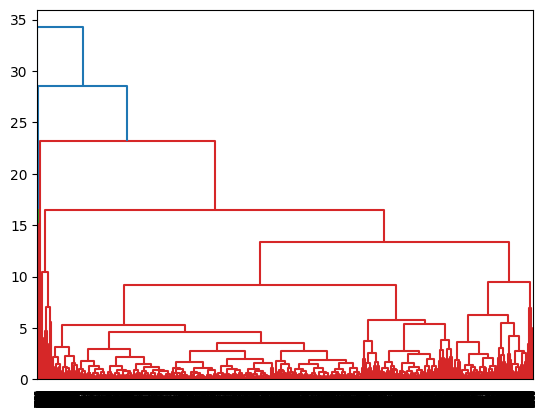

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

#link = linkage(data_scaled, method='ward')
link = linkage(data_scaled, method='complete')

dendrogram(link);
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Control
n_clusters = 2

# Agglomerative models using df_num_scaled
model_ward = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_ward = model_ward.fit_predict(data_scaled)

model_complete = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
labels_complete = model_complete.fit_predict(data_scaled)

model_average = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')
labels_average = model_average.fit_predict(data_scaled)

model_single = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
labels_single = model_single.fit_predict(data_scaled)

# Crosstabs vs KMeans labels with named axes
ct_ward = pd.crosstab(
    index=pd.Series(labels_ward, name='ward'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

ct_complete = pd.crosstab(
    index=pd.Series(labels_complete, name='complete'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

ct_average = pd.crosstab(
    index=pd.Series(labels_average, name='average'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

ct_single = pd.crosstab(
    index=pd.Series(labels_single, name='single'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

print("\nWard vs KMeans")
display(ct_ward)

ari = adjusted_rand_score(labels_kmeans, labels_ward)
ami = adjusted_mutual_info_score(labels_kmeans, labels_ward)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")
print()

print("\nComplete vs KMeans")
display(ct_complete)

ari = adjusted_rand_score(labels_kmeans, labels_complete)
ami = adjusted_mutual_info_score(labels_kmeans, labels_complete)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")
print()

print("\nAverage vs KMeans")
display(ct_average)

ari = adjusted_rand_score(labels_kmeans, labels_average)
ami = adjusted_mutual_info_score(labels_kmeans, labels_average)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")
print()

print("\nSingle vs KMeans")
display(ct_single)

ari = adjusted_rand_score(labels_kmeans, labels_single)
ami = adjusted_mutual_info_score(labels_kmeans, labels_single)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")


Ward vs KMeans


kmeans,0,1,All
ward,,,
0,307,7308,7615
1,1238,97,1335
All,1545,7405,8950


ARI: 0.781
AMI: 0.630


Complete vs KMeans


kmeans,0,1,All
complete,,,
0,1540,7405,8945
1,5,0,5
All,1545,7405,8950


ARI: 0.004
AMI: 0.004


Average vs KMeans


kmeans,0,1,All
average,,,
0,1544,7405,8949
1,1,0,1
All,1545,7405,8950


ARI: 0.001
AMI: 0.001


Single vs KMeans


kmeans,0,1,All
single,,,
0,1544,7405,8949
1,1,0,1
All,1545,7405,8950


ARI: 0.001
AMI: 0.001


Various linkage methods were used for agglomerative clustering that inspected n_cluster=2

Ward vs KMeans


*   ARI of 0.781 and AMI of 0.630.
*   Moderate agreement similar to GMM


Complete vs KMeans

*   ARI of 0.004 and AMI of 0.004.
*   Very low agreement suggesting completee linkage produces a verry different clustering structure compared to K-Means

Average vs KMeans

*   ARI of 0.003 and AMI of 0.003.
*   Essentially no agreement

Single vs KMeans

*   ARI of 0.000 and AMI of 0.000.
*   Essentially no agreement

Ward linkage shows the highest agreement with K-Means, which is expected as both tend to create spherical clusters. Other linkage methods (complete, average, single) produce very different and likely less balanced clusterings for this dataset when compared to K-Means

#Spectral Clustering

In [ ]:
from sklearn.cluster import SpectralClustering

# Control
n_clusters = 2

# Spectral Clustering
model_spectral = SpectralClustering(
    n_clusters=n_clusters,
    affinity='nearest_neighbors',
    n_neighbors=50,
    random_state=42
)
labels_spectral = model_spectral.fit_predict(data_scaled)

# Crosstab: Spectral vs KMeans
ct_spectral = pd.crosstab(
    index=pd.Series(labels_spectral, name='spectral'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

print("\nSpectral vs KMeans")
display(ct_spectral)

# Agreement scores
ari = adjusted_rand_score(labels_kmeans, labels_spectral)
ami = adjusted_mutual_info_score(labels_kmeans, labels_spectral)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")


Spectral vs KMeans


kmeans,0,1,All
spectral,,,
0,1545,2944,4489
1,0,4461,4461
All,1545,7405,8950


ARI: 0.117
AMI: 0.238


Spectral clustering is good for non-globularr clusters and have a differrent structure in the data thaan K-Means which assume spherical clusters

ARI of 0.117 and AMI of 0.238

# Mean shift

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# Estimate bandwidth
bandwidth = estimate_bandwidth(data_scaled, quantile=0.2)
bandwidth = 4
print(f"Estimated bandwidth: {bandwidth:.3f}")

# MeanShift with estimated bandwidth
model_meanshift = MeanShift(bandwidth=bandwidth, cluster_all=False)
labels_meanshift = model_meanshift.fit_predict(data_scaled)

# Crosstab: MeanShift vs KMeans
ct_meanshift = pd.crosstab(
    index=pd.Series(labels_meanshift, name='meanshift'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

print("\nMeanShift vs KMeans")
display(ct_meanshift)

# Agreement scores
ari = adjusted_rand_score(labels_kmeans, labels_meanshift)
ami = adjusted_mutual_info_score(labels_kmeans, labels_meanshift)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")

Estimated bandwidth: 4.000

MeanShift vs KMeans


kmeans,0,1,All
meanshift,,,
-1,562,374,936
0,954,7031,7985
1,19,0,19
2,4,0,4
3,2,0,2
4,1,0,1
5,1,0,1
6,1,0,1
7,1,0,1


ARI: 0.314
AMI: 0.153


Estimate bandwith suggest an optimal bandwith.

Meanshift vs KMeans have a low agreeement . Meanshift does not reequire specifying the number of clusters beforehand but find them based on density. The agreement with K-Means suggestthe desnity based clusters are some what differrent from centroid based clusters

#Density-Based Spatial Clustering of Application with Noise

,-1,0,1,2,3,4,5,6,7,8,9,10
count,368,8480,33,10,8,6,8,11,8,5,7,6


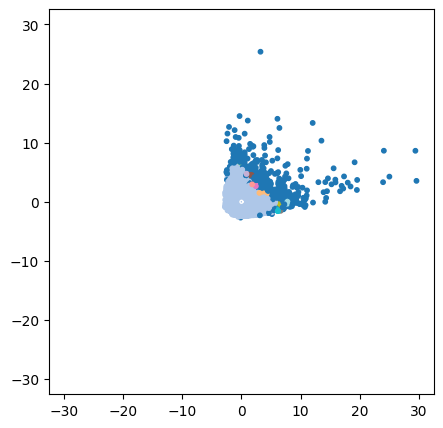

In [ ]:
from sklearn.cluster import DBSCAN

radius      = 0.25
min_samples = 5

# Find clusters
model = DBSCAN(
    eps=radius,
    min_samples=min_samples
)
labels = model.fit_predict(data_scaled)

display(pd.DataFrame(pd.Series(labels).value_counts().sort_index()).T)

# Plot
cmap = 'tab20'

plt.figure(figsize=(5,5))

theta = np.linspace(0,2*np.pi,100)
c = radius * np.cos(theta)
s = radius * np.sin(theta)

plt.plot(c, s, linewidth=1, c='w')

# Define MAX_VAL for plot limits
MAX_VAL = np.abs(data_scaled.values).max() * 1.1

# Use .iloc for DataFrame column access
plt.scatter(data_scaled.iloc[:,0], data_scaled.iloc[:,1], c=labels, s=10, cmap=cmap);
plt.xlim(-MAX_VAL,MAX_VAL)
plt.ylim(-MAX_VAL,MAX_VAL)
plt.gca().set_aspect('equal')
plt.show()

# Changing the DBSCAN radius

radius: 0.01


,-1,0,1,2,3,4,5
count,8883,23,20,8,5,5,6


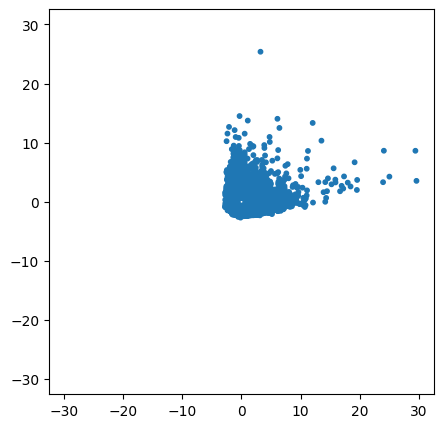

radius: 0.06271603868184097


,-1,0,1,2,3,4,5,6,7,8,...,115,116,117,118,119,120,121,122,123,124
count,2831,4642,23,21,6,19,11,35,51,18,...,5,5,5,7,5,5,5,5,4,4


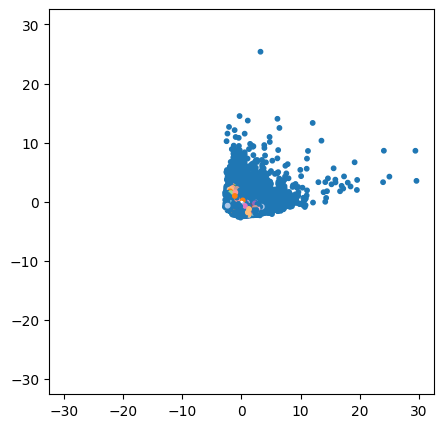

radius: 0.11543207736368194


,-1,0,1,2,3,4,5,6,7,8,...,41,42,43,44,45,46,47,48,49,50
count,1128,7373,13,15,10,9,5,7,7,6,...,3,4,5,5,5,5,5,5,6,5


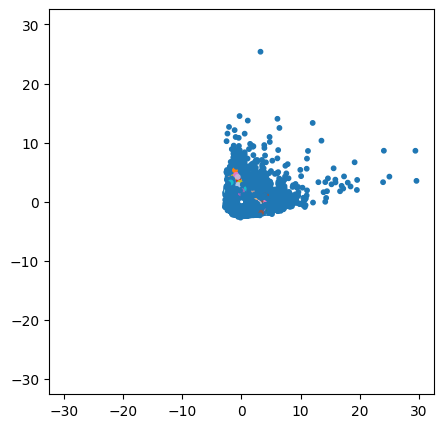

radius: 0.16814811604552293


,-1,0,1,2,3,4,5,6,7,8,...,18,19,20,21,22,23,24,25,26,27
count,659,8032,17,31,9,35,13,12,6,6,...,6,12,4,7,5,4,5,4,6,8


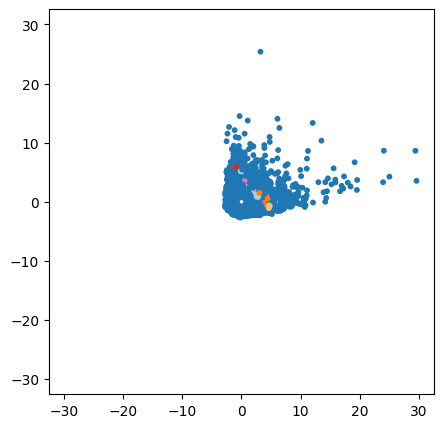

radius: 0.2208641547273639


,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,441,8398,11,8,6,20,2,7,11,10,7,7,5,7,10


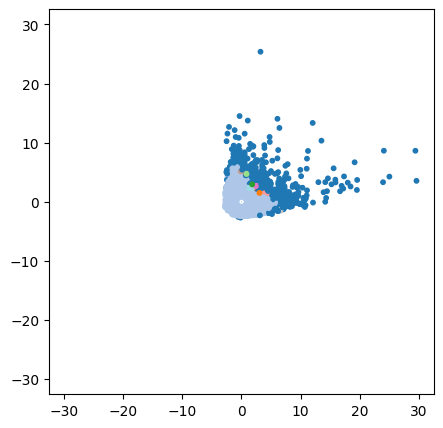

radius: 0.27358019340920486


,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,331,8504,32,10,12,6,8,10,5,5,5,7,4,6,5


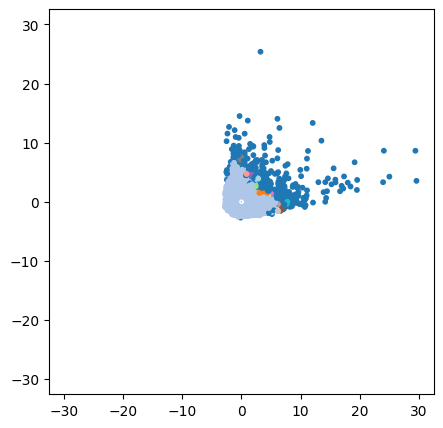

radius: 0.32629623209104586


,-1,0,1,2,3,4,5,6,7,8
count,254,8624,7,26,5,13,5,5,6,5


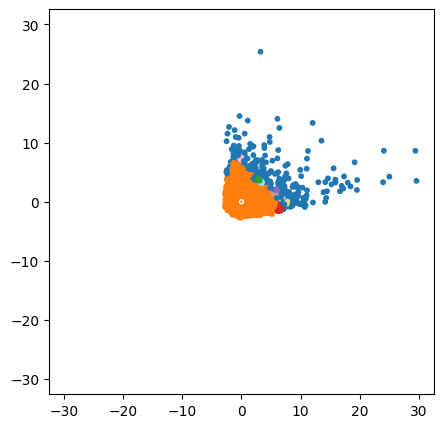

radius: 0.3790122707728868


,-1,0,1,2,3,4,5,6,7,8
count,214,8685,9,6,6,5,8,5,5,7


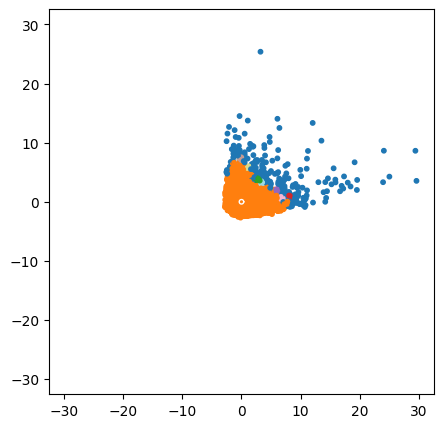

radius: 0.4317283094547278


,-1,0,1,2,3,4,5,6
count,166,8736,15,10,8,5,5,5


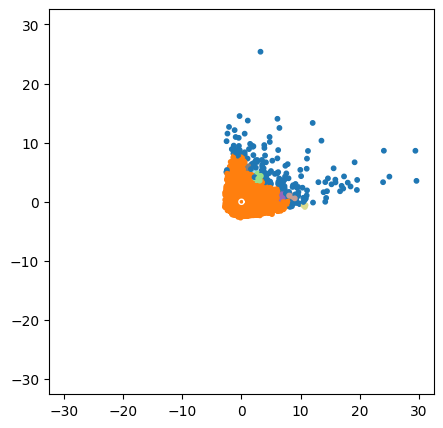

radius: 0.4844443481365688


,-1,0,1,2,3,4
count,139,8785,8,6,6,6


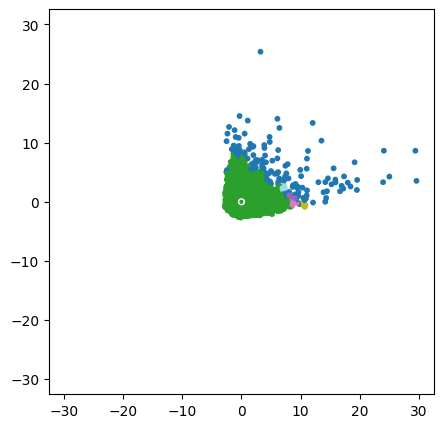

radius: 0.5371603868184097


,-1,0,1,2,3
count,118,8809,12,5,6


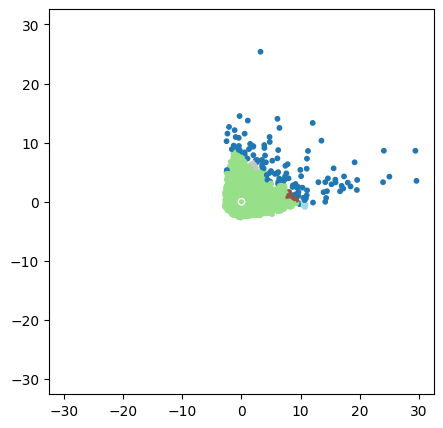

radius: 0.5898764255002507


,-1,0,1
count,107,8836,7


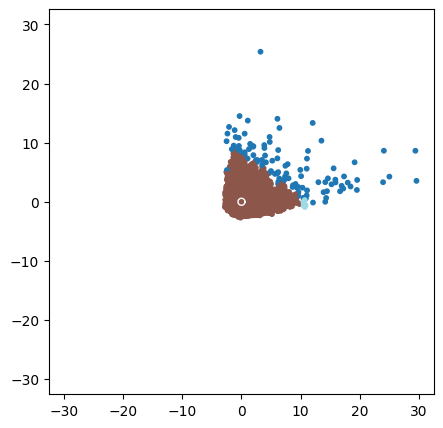

radius: 0.6425924641820917


,-1,0
count,97,8853


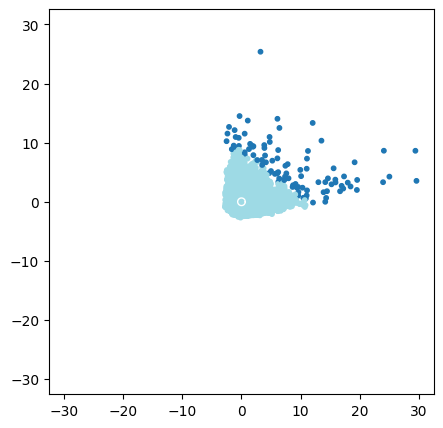

radius: 0.6953085028639326


,-1,0
count,86,8864


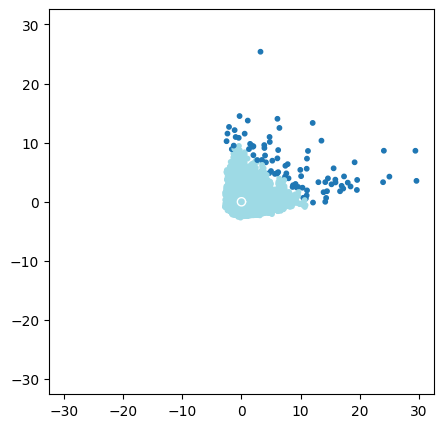

radius: 0.7480245415457736


,-1,0,1
count,77,8868,5


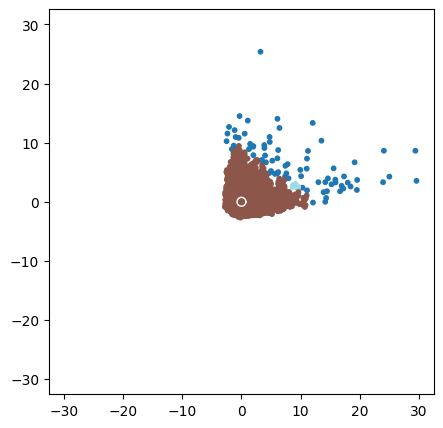

radius: 0.8007405802276146


,-1,0,1,2
count,65,8875,5,5


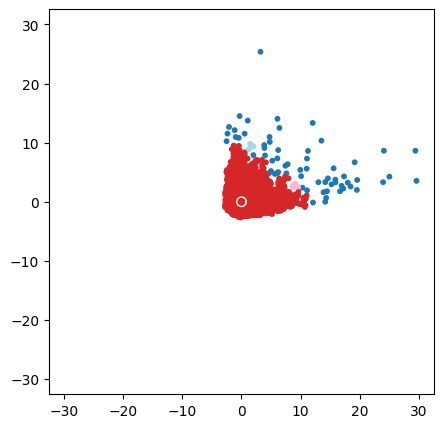

radius: 0.8534566189094556


,-1,0,1,2
count,58,8882,5,5


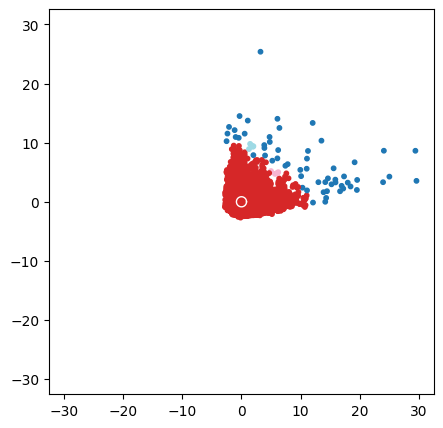

radius: 0.9061726575912965


,-1,0,1
count,56,8889,5


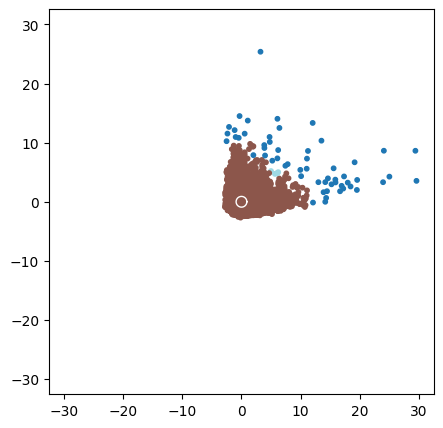

radius: 0.9588886962731376


,-1,0
count,54,8896


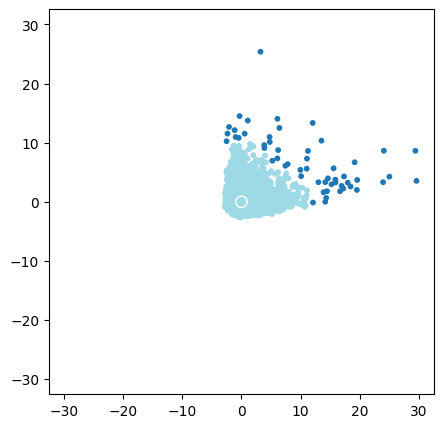

radius: 1.0116047349549784


,-1,0
count,54,8896


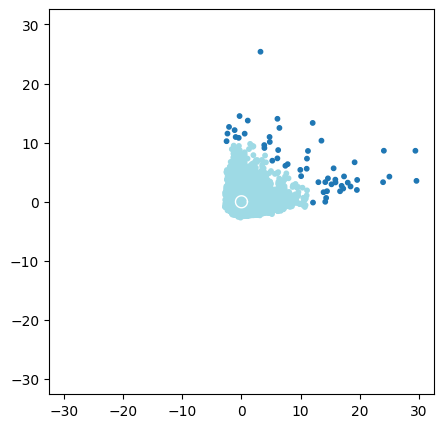

radius: 1.0643207736368194


,-1,0
count,54,8896


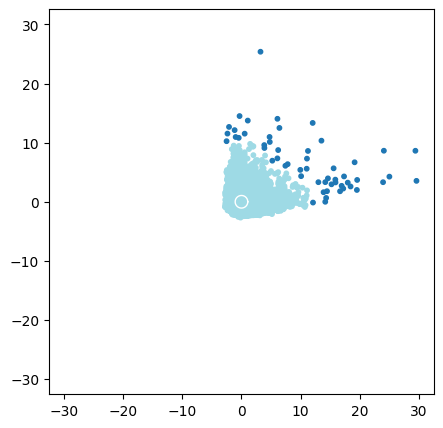

radius: 1.1170368123186605


,-1,0
count,53,8897


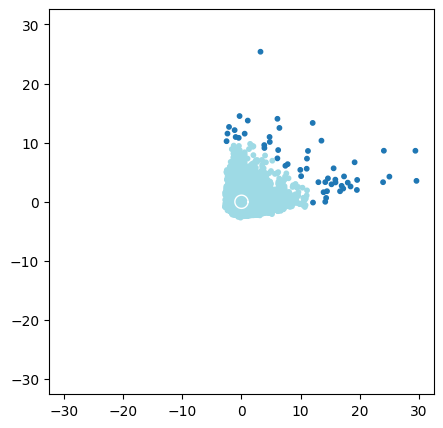

radius: 1.1697528510005013


,-1,0
count,53,8897


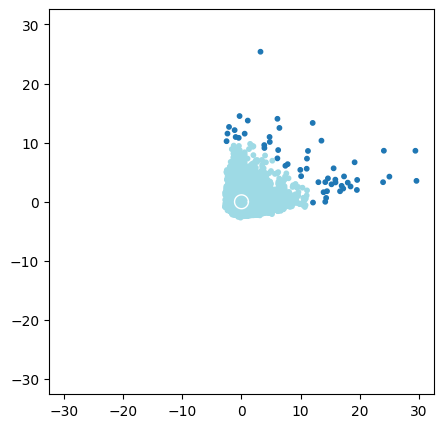

radius: 1.2224688896823424


,-1,0,1,2
count,44,8897,5,4


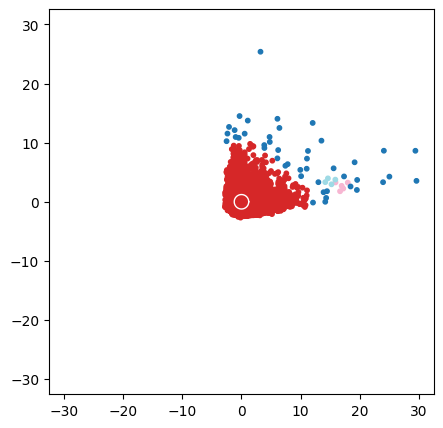

radius: 1.2751849283641834


,-1,0,1,2
count,42,8897,7,4


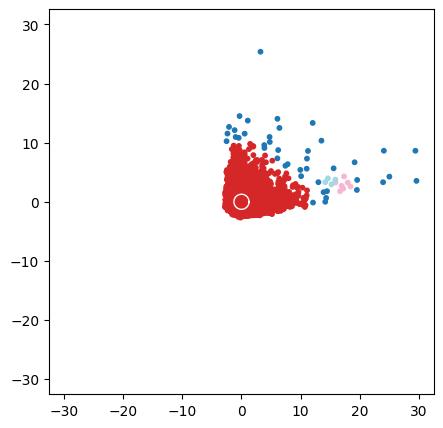

radius: 1.3279009670460242


,-1,0,1,2
count,40,8899,7,4


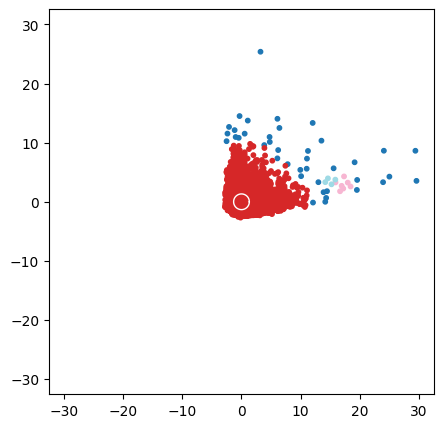

radius: 1.3806170057278653


,-1,0,1,2
count,38,8901,7,4


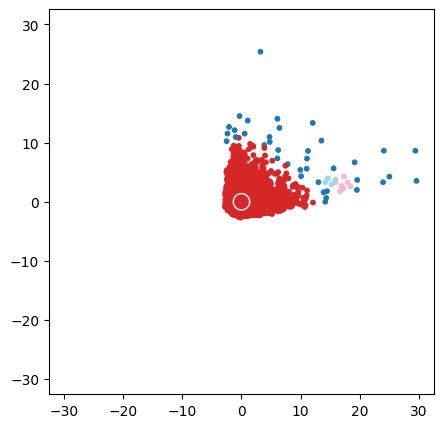

radius: 1.4333330444097063


,-1,0,1,2
count,36,8902,7,5


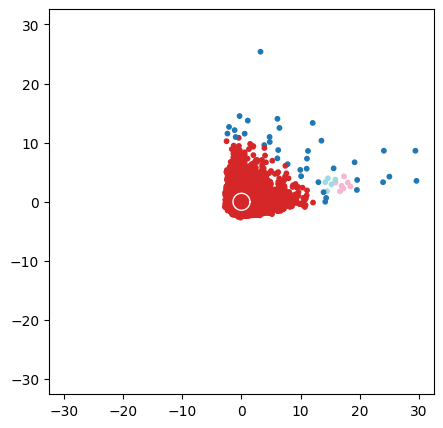

radius: 1.4860490830915472


,-1,0,1
count,31,8907,12


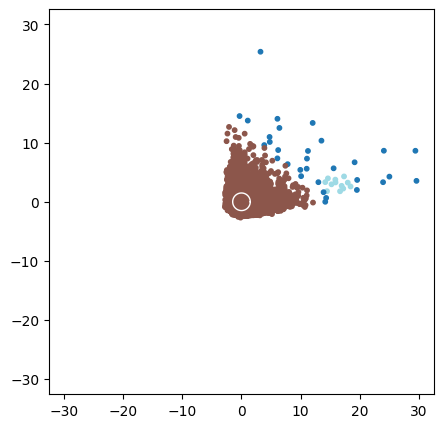

radius: 1.5387651217733882


,-1,0,1
count,30,8907,13


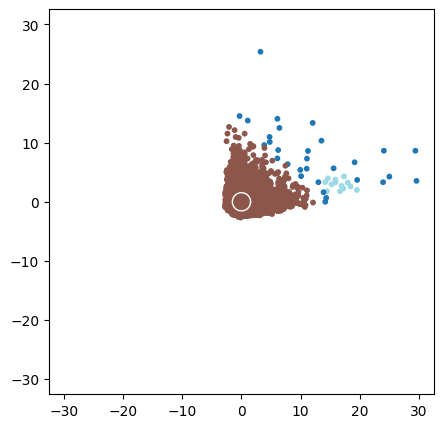

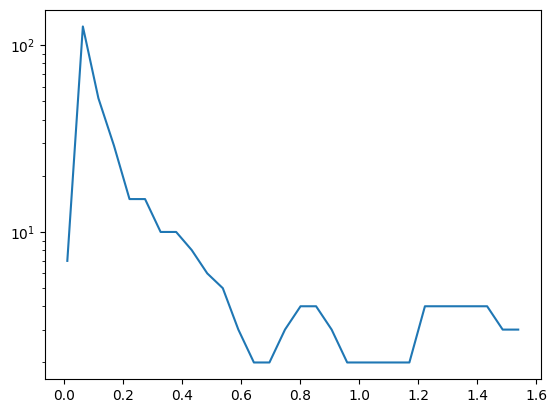

In [ ]:
from sklearn.cluster import estimate_bandwidth

radii = np.linspace(
    0.01,
    estimate_bandwidth(data_scaled, quantile=0.15),
    30
)

min_samples = 5

n_clusters = []

for r in radii:
    model = DBSCAN(eps=r, min_samples=min_samples)
    labels = model.fit_predict(data_scaled)
    labels = pd.Series(labels)

    vc = labels.value_counts()

    n_clusters.append( vc.shape[0] )

    # treat outliers as separate classes
    """
    try:
        n_clusters.append( vc.shape[0] - 1 + vc[-1] )
    except:
        n_clusters.append( vc.shape[0] )
    # end
    """

    print(f"radius: {r}")
    display(pd.DataFrame(pd.Series(labels).value_counts().sort_index()).T)

    # Plot
    cmap = 'tab20'

    plt.figure(figsize=(5,5))

    theta = np.linspace(0,2*np.pi,100)
    c = r * np.cos(theta)
    s = r * np.sin(theta)

    plt.plot(c, s, linewidth=1, c='w')

    MAX_VAL = np.abs(data_scaled.values).max() * 1.1

    plt.scatter(data_scaled.iloc[:,0], data_scaled.iloc[:,1], c=labels, s=10, cmap=cmap);
    plt.xlim(-MAX_VAL,MAX_VAL)
    plt.ylim(-MAX_VAL,MAX_VAL)
    plt.gca().set_aspect('equal')
    plt.show()

# end

plt.semilogy( radii, n_clusters )
plt.show()

       -1     0    1    2    3    4    5    6    7    8    9    10
count  368  8480   33   10    8    6    8   11    8    5    7    6


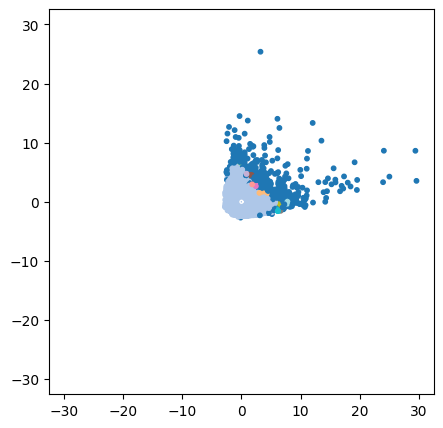

In [ ]:
from sklearn.cluster import DBSCAN

# Find clusters
model = DBSCAN(eps=radius, min_samples=5)
labels = model.fit_predict(data_scaled)

print(pd.DataFrame(pd.Series(labels).value_counts().sort_index()).T)

# Plot
plt.figure(figsize=(5,5))

theta = np.linspace(0,2*np.pi,100)
c = radius * np.cos(theta)
s = radius * np.sin(theta)

plt.plot(c, s, linewidth=1, c='w')

# Define MAX_VAL for plot limits
MAX_VAL = np.abs(data_scaled.values).max() * 1.1

# Use .iloc for DataFrame column access
plt.scatter(data_scaled.iloc[:,0], data_scaled.iloc[:,1], c=labels, s=10, cmap=cmap);
plt.xlim(-MAX_VAL,MAX_VAL)
plt.ylim(-MAX_VAL,MAX_VAL)
plt.gca().set_aspect('equal')
plt.show()

Output shows 368 points are labeled as -1 (noise) for a radiuos of 0.25, the majority are noise only a small cluster were formed.

Iteration over different radius was done to minimize the noisee point. The n_clusters shows how many clusters werre found forr each radius

Overall, the analysis shows that k=2 and k=3 are porteenital for K-Means aand GMM based on silhouettee,AIC and BIC. Howeverr GMM had a negative silhouettee scoree for one clusterr with k=2. The agreeement between different clusterring algorithm varries widely with Ward agglomerative clustering showing the highest similarity to K-Means. DBSCAN with a small radius identifieda large numbeer of noise point identifying the data might not be dense eenough in distinct regon.